In [2]:
import h5py
import numpy as np
import matplotlib.pyplot as plt

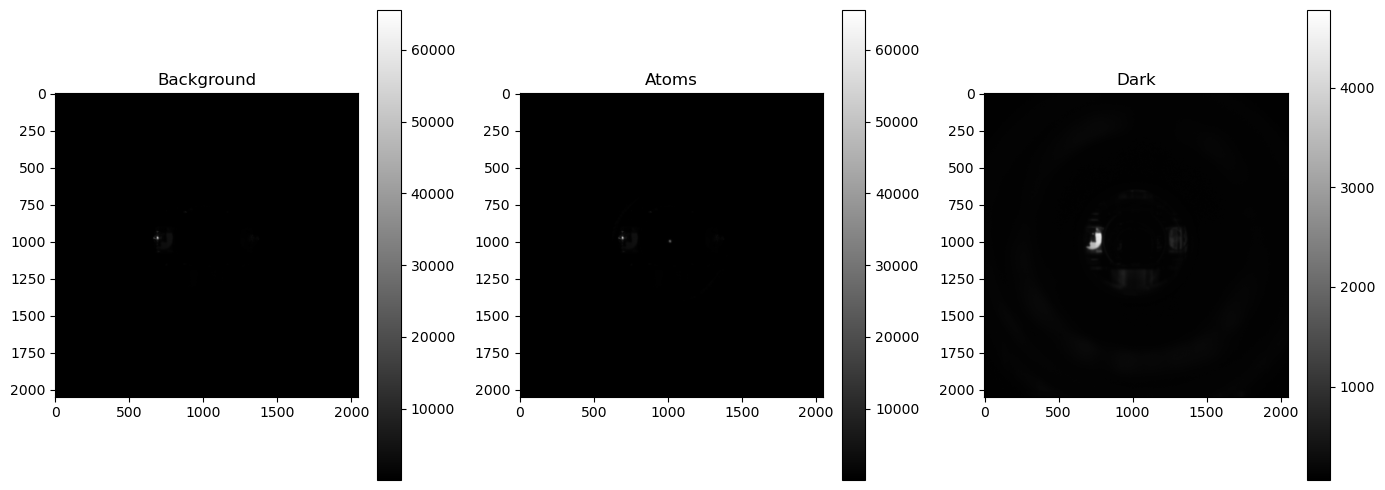

In [42]:
shot_file = r"D:\LiCs_Exp_Data\Experiments\lics_labscript_apparatus\seq_CsImaging\2026\07\07\0011\2026-07-07_0011_seq_CsImaging_0.h5"

with h5py.File(shot_file, 'r') as f:
    dark       = f['images/pco_panda/fluorescence/dark'][:]
    background = f['images/pco_panda/fluorescence/background'][:]
    atoms      = f['images/pco_panda/fluorescence/atoms'][:]

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
im0 = axes[0].imshow(background, cmap='gray', origin='upper')
axes[0].set_title('Background')
plt.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(atoms, cmap='gray', origin='upper')
axes[1].set_title('Atoms')
plt.colorbar(im1, ax=axes[1])

im2 = axes[2].imshow(dark, cmap='gray', origin='upper')
axes[2].set_title('Dark')
plt.colorbar(im2, ax=axes[2])

plt.tight_layout()
plt.show()


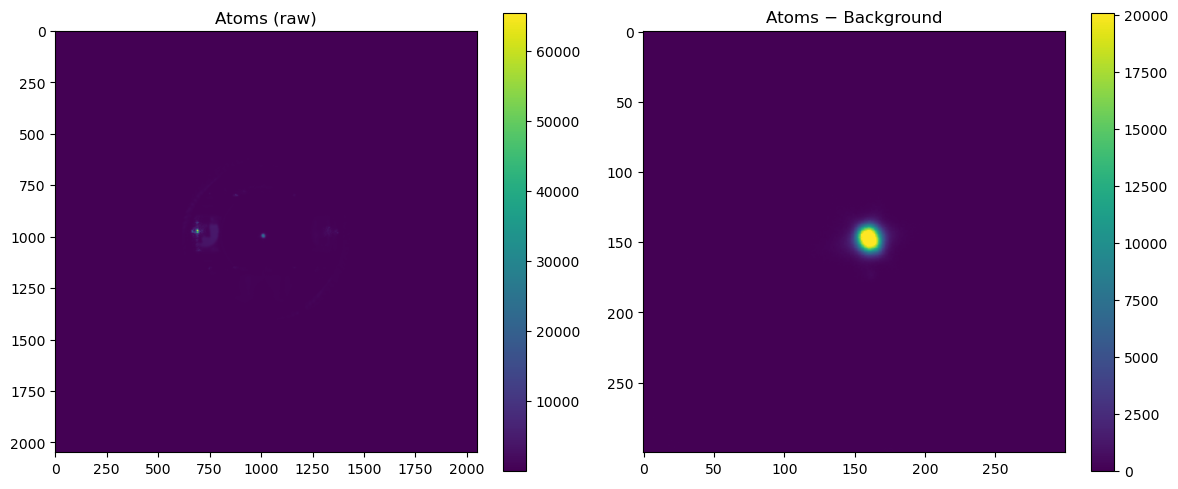

MOT peak at row=996, col=1009


In [46]:
diff = atoms.astype(float) - background.astype(float)
#crop out the ring
cx, cy, r = 1000, 1000, 150
diff_crop = diff[cy-r:cy+r, cx-r:cx+r]

#plot the difference image and the raw atoms image side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
im0 = axes[0].imshow(atoms, cmap='viridis', origin='upper')
axes[0].set_title('Atoms (raw)')
plt.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(diff_crop, cmap='viridis', origin='upper',
                     vmin=0, vmax=np.percentile(diff_crop, 99.9))
axes[1].set_title('Atoms − Background')
plt.colorbar(im1, ax=axes[1])
plt.tight_layout()
plt.show()

peak = np.unravel_index(np.argmax(diff), diff.shape)
print(f"MOT peak at row={peak[0]}, col={peak[1]}")
# then use cy=peak[0], cx=peak[1]


Calculate Atom Number

In [50]:
# Relevant Cesium Constants
gamma = 2 * np.pi * 5.234e6 #D2 transition linewidth in Hz
I_sat = 27.119 #F=4 to F=5 saturation intensity in W/m^2
w0 = 2 * np.pi * 351.72571750e12 #D2 transition frequency in Hz

#measured quantities
w = w0 # laser frequency in Hz (assume on resonance)
r_beam = (2.54e-2)/2
p_tot = 24.3e-3 + 21.4e-3 + 22.8e-3 # total laser power in W
A_beam = np.pi * r_beam**2 # laser beam area in m^2
I = 2 * p_tot/A_beam # laser intensity in W/m^2

r_lens = 8e-3 # radius of the imaging lens in m
d = 11 * 2.54e-2 # distance from atoms to lens in m (number of holes * 2.54 cm/hole)
sa = np.pi * r_lens**2 / d**2 #solid angle of the imaging lens
eta = sa/ (4 * np.pi) #collection efficiency of the imaging lens

#camera parameters
QE = 1/0.42 #device quantum efficiency of the camera = 1/quantum efficiency
t_exp = 100e-3 #exposure time in seconds

# Calculate the number of atoms in the image
N_c = np.sum(diff_crop) #number of counts in the image

rho_ee = 0.5 * (I/I_sat) / (1 + I/I_sat + 4 * ((w - w0)/gamma)**2) #excited state population fraction

N_a = (N_c * QE) / (rho_ee * gamma * eta * t_exp) #number of atoms in the image

print(f"Estimated number of atoms in the image: {N_a:.2e}")


Estimated number of atoms in the image: 5.46e+04
